In [8]:
import numpy as np
import matplotlib.pyplot as plt

Aprox

In [9]:
import numpy as np

def solve(A, b):
    Q, R = np.linalg.qr(A, mode='reduced')
    
    c = Q.T @ b
    
    n = A.shape[1]
    x = np.zeros(n)
    
    for k in range(n - 1, -1, -1):
        suma = 0
        for j in range(k + 1, n):
            suma += R[k, j] * x[j]
            
        x[k] = (c[k] - suma) / R[k, k]
        
    return x

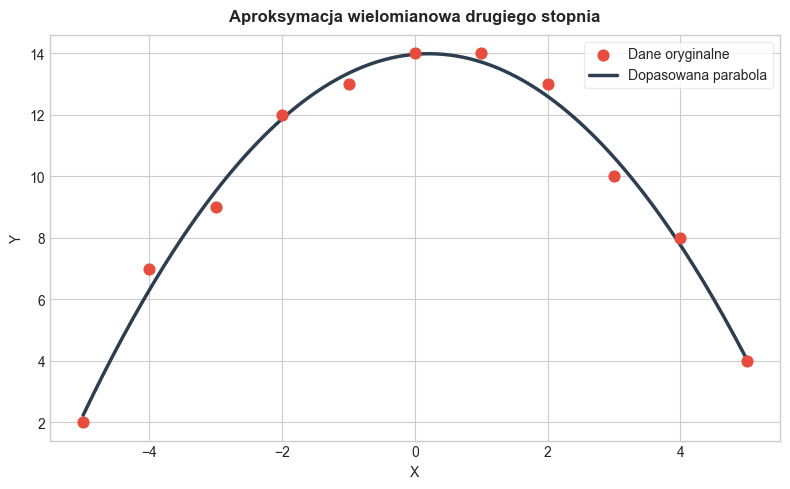

In [22]:
import matplotlib.pyplot as plt
import numpy as np

X_orig = np.array([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
Y = np.array([2, 7, 9, 12, 13, 14, 14, 13, 10, 8, 4])
n = X_orig.shape[0]

ones = np.ones(n)
x_sq = np.power(X_orig, 2)

X_matrix = np.vstack((ones, X_orig, x_sq)).T

alfas = solve(X_matrix.T @ X_matrix, X_matrix.T @ Y)


plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)

ax.scatter(X_orig, Y, color='#e74c3c', s=60, zorder=5, label='Dane oryginalne')

x_smooth = np.linspace(-5, 5, 200)
y_smooth = alfas[0] + alfas[1] * x_smooth + alfas[2] * (x_smooth**2)

ax.plot(x_smooth, y_smooth, color='#2c3e50', lw=2.5, label='Dopasowana parabola')

ax.set_title('Aproksymacja wielomianowa drugiego stopnia', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('X', fontsize=10)
ax.set_ylabel('Y', fontsize=10)
ax.legend(frameon=True, facecolor='white', edgecolor='0.9')

plt.tight_layout()
plt.show()